#AML Risk Analysis of Global Financial Transactions

##Project overview

This project analyzes financial transactions to identify patterns associated with money laundering risk. The goal is to discover trends across transaction types, countries, industries, transaction amounts, sources of money, and other risk-related factors. The analysis was conducted using Python and Pandas, with visualizations created to highlight key findings and patterns in the data.

##Objectives

1. Analyze transaction patterns across transaction types, countries, and industries.
2. Examine transaction amounts and identify countries/industries with the highest financial activity.
3. Investigate factors associated with money laundering risk, including industry, country, transaction type, amount, and shell companies.
4. Compare legal and illegal sources of money and their relationship with risk scores and reported transactions.
5. Analyze temporal patterns in transaction volume and risk scores.

##Data cleaning

1. Converted Date of Transaction to datetime format.
2. Checked for missing values.
3. Checked for duplicate records.
4. Formatted Amount (USD) values for readability.
5. Checked data types.

In [30]:
import pandas as pd
import numpy as np
import plotly as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df=pd.read_csv("Big_Black_Money_Dataset.csv")
df.head()

,Transaction ID,Country,Amount (USD),Transaction Type,Date of Transaction,Person Involved,Industry,Destination Country,Reported by Authority,Source of Money,Money Laundering Risk Score,Shell Companies Involved,Financial Institution,Tax Haven Country
0,TX0000000001,Brazil,"3,267,530.48",Offshore Transfer,2013-01-01 00:00:00,Person_1101,Construction,USA,True,Illegal,6,1,Bank_40,Singapore
1,TX0000000002,China,"4,965,766.73",Stocks Transfer,2013-01-01 01:00:00,Person_7484,Luxury Goods,South Africa,False,Illegal,9,0,Bank_461,Bahamas
2,TX0000000003,UK,"94,167.50",Stocks Transfer,2013-01-01 02:00:00,Person_3655,Construction,Switzerland,True,Illegal,1,3,Bank_387,Switzerland
3,TX0000000004,UAE,"386,420.14",Cash Withdrawal,2013-01-01 03:00:00,Person_3226,Oil & Gas,Russia,False,Illegal,7,2,Bank_353,Panama
4,TX0000000005,South Africa,"643,378.43",Cryptocurrency,2013-01-01 04:00:00,Person_7975,Real Estate,USA,True,Illegal,1,9,Bank_57,Luxembourg


In [12]:
df.shape

(10000, 14)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction ID               10000 non-null  object 
 1   Country                      10000 non-null  object 
 2   Amount (USD)                 10000 non-null  float64
 3   Transaction Type             10000 non-null  object 
 4   Date of Transaction          10000 non-null  object 
 5   Person Involved              10000 non-null  object 
 6   Industry                     10000 non-null  object 
 7   Destination Country          10000 non-null  object 
 8   Reported by Authority        10000 non-null  bool   
 9   Source of Money              10000 non-null  object 
 10  Money Laundering Risk Score  10000 non-null  int64  
 11  Shell Companies Involved     10000 non-null  int64  
 12  Financial Institution        10000 non-null  object 
 13  Tax Haven Country

In [14]:
df.isnull().sum()

Transaction ID                 0
Country                        0
Amount (USD)                   0
Transaction Type               0
Date of Transaction            0
Person Involved                0
Industry                       0
Destination Country            0
Reported by Authority          0
Source of Money                0
Money Laundering Risk Score    0
Shell Companies Involved       0
Financial Institution          0
Tax Haven Country              0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Date of Transaction"].dtype

dtype('O')

In [66]:
df["Date of Transaction"]=pd.to_datetime(df["Date of Transaction"])

In [67]:
df["Date of Transaction"].dtype

dtype('<M8[ns]')

In [20]:
df["Amount (USD)"].head()

0    3.267530e+06
1    4.965767e+06
2    9.416750e+04
3    3.864201e+05
4    6.433784e+05
Name: Amount (USD), dtype: float64

In [21]:
pd.set_option('display.float_format', '{:,.2f}'.format)

##Transaction Types 

The analysis shows the distribution of transactions across different transaction types.

In [24]:
df["Transaction Type"].value_counts()

Transaction Type
Property Purchase    2086
Stocks Transfer      1983
Offshore Transfer    1980
Cash Withdrawal      1978
Cryptocurrency       1973
Name: count, dtype: int64

##Insight

Property Purchase was the most frequent transaction type, while offshore Transfer and Cash Withdrawal had similar transaction volumes.

##Risk Score by Transaction Types

Analyzes the average money laundering risk score across different transaction types.

In [26]:
df.groupby("Transaction Type")["Money Laundering Risk Score"].mean().sort_values(ascending=False)

Transaction Type
Stocks Transfer     5.60
Cash Withdrawal     5.55
Property Purchase   5.51
Cryptocurrency      5.51
Offshore Transfer   5.47
Name: Money Laundering Risk Score, dtype: float64

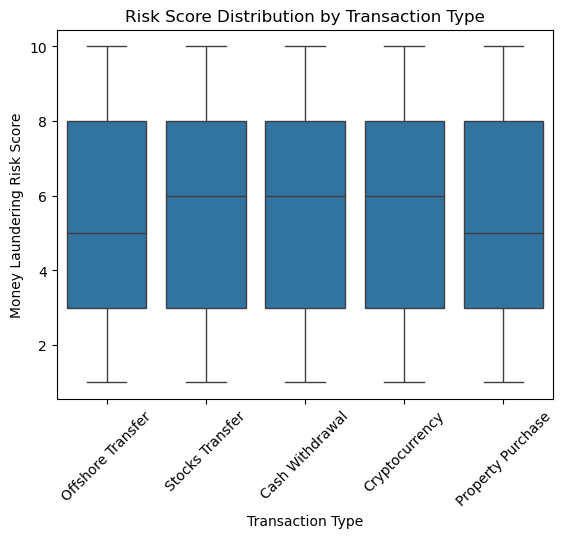

In [36]:
sns.boxplot(
    data=df,
    x="Transaction Type",
    y="Money Laundering Risk Score"
)

plt.xticks(rotation=45)
plt.title("Risk Score Distribution by Transaction Type")
plt.show()

##Insight

Average money laundering risk scores were very similar across transaction types, ranging from 5.47 for offshore Transfer to 5.60 for Stocks Transfer. This suggests that transaction type has little influence on the risk score in this dataset.

##Source of Money Distribution

Analyze the distribution of transactions by source of money.

In [40]:
df["Source of Money"].value_counts()

Source of Money
Illegal    7017
Legal      2983
Name: count, dtype: int64

##Insight

Most transactions were classified as illegal sources of money, while a smaller proportion were classified as legal.

##Risk Score by Source of Money

Analyze the average money laundering risk score for legal and illegal sources of money.

In [42]:
df.groupby("Source of Money") ["Money Laundering Risk Score"].mean()

Source of Money
Illegal   5.53
Legal     5.52
Name: Money Laundering Risk Score, dtype: float64

##Insight

The average risk scores for legal and illegal sources of money were nearly identical, indicating little difference in risk score between the two categories.

##Top 10 Countries by Transaction Volume

Identify the countries with the highest number of financial transactions.

In [43]:
df["Country"].value_counts().head(10)

Country
China           1038
South Africa    1026
UK              1014
Brazil          1006
Russia           997
Singapore        995
India            990
Switzerland      985
UAE              976
USA              973
Name: count, dtype: int64

##Insight

China had the highest number of transactions, followed by South Africa and the UK.

##Top 10 Countries by Total Transaction Amount

Identify the countries with the highest total transaction amounts.

In [44]:
df.groupby("Country")["Amount (USD)"].sum().sort_values(ascending=False).head(10)

Country
China          2,691,667,427.20
South Africa   2,576,112,428.17
UK             2,527,722,987.58
Brazil         2,513,360,480.42
Singapore      2,495,846,085.67
Russia         2,494,146,366.74
Switzerland    2,479,311,763.79
India          2,467,652,868.91
UAE            2,430,288,279.26
USA            2,342,067,957.93
Name: Amount (USD), dtype: float64

##Insight

China had the highest total transaction amount, followed by South Africa and the UK.

##Top 10 Countries by Average Transaction Amounts

Identify the countries with the highest average transaction amounts.

In [45]:
df.groupby("Country")["Amount (USD)"].mean().sort_values(ascending=False).head(10)

Country
China          2,593,128.54
Switzerland    2,517,067.78
South Africa   2,510,830.83
Singapore      2,508,388.03
Russia         2,501,651.32
Brazil         2,498,370.26
UK             2,492,823.46
India          2,492,578.66
UAE            2,490,049.47
USA            2,407,058.54
Name: Amount (USD), dtype: float64

##Insight

China has the highest average transaction amount, followed by Switzerland.

##Top Industries by Transaction Volume

Identify the industries with the highest number of financial transactions.

In [50]:
df["Industry"].value_counts().head(10)

Industry
Finance         1475
Construction    1460
Luxury Goods    1459
Real Estate     1443
Arms Trade      1414
Casinos         1377
Oil & Gas       1372
Name: count, dtype: int64

##Insight

Finance had the highest number of transactions (1,475), followed by Construction (1,460). Oil & Gas had the fewest transactions among the listed industries (1,372).

##Top Industries by Total Transaction Amount

Identify the industries with the highest total transaction amounts.

In [52]:
df.groupby("Industry")["Amount (USD)"].sum().sort_values(ascending=False).head(10)

Industry
Finance        3,735,922,688.05
Construction   3,705,738,369.43
Arms Trade     3,600,556,018.64
Luxury Goods   3,597,892,992.36
Real Estate    3,575,935,941.77
Casinos        3,418,471,776.49
Oil & Gas      3,383,658,858.93
Name: Amount (USD), dtype: float64

##Insight

Finance had the highest total transaction amount at approximately $3.74 billion, followed by Construction at $3.71 billion. Oil & Gas had the lowest total transaction amount among the industries at approximately $3.38 billion.

##Top Industries by Average Transaction Amount

Identify the industries with the highest average transaction amounts.

In [53]:
df.groupby("Industry")["Amount (USD)"].mean().sort_values(ascending=False).head(10)

Industry
Arms Trade     2,546,362.11
Construction   2,538,176.97
Finance        2,532,828.94
Casinos        2,482,550.31
Real Estate    2,478,126.09
Oil & Gas      2,466,223.66
Luxury Goods   2,465,999.31
Name: Amount (USD), dtype: float64

##Insight

Arms Trade had the highest average transaction amount at approximately $2.55 million, while Luxury Goods had the lowest at approximately $2.47 million. The differences between industries were relatively small.

##Risk Score Distribution by Source of Money

Analyze the distribution of money laundering risk scores for legal and illegal sources of money.

In [54]:
df.groupby("Source of Money")["Money Laundering Risk Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Source of Money,,,,,,,,
Illegal,"7,017.00",5.53,2.89,1.00,3.00,6.00,8.00,10.00
Legal,"2,983.00",5.52,2.90,1.00,3.00,6.00,8.00,10.00


Insight

The average risk scores were nearly identical for illegal (5.53) and legal (5.52) sources of money. Both categories also had similar variability and the same minimum and maximum risk scores, suggesting little difference in risk distribution between the two sources.

##Reported Transactions by Source of Money

Analyze the percentage of transactions reported to authorities for legal and illegal sources of money.

In [55]:
pd.crosstab(
    df["Source of Money"],
    df["Reported by Authority"],
    normalize="index"
)*100
    

Reported by Authority,False,True
Source of Money,,
Illegal,80.03,19.97
Legal,79.75,20.25


##Insight

The percentage of reported transactions was very similar for illegal (19.97%) and legal (20.25%) sources of money. This suggests that the source of money was not strongly associated with whether a transaction was reported to the authorities in this dataset.

##Money Laundering Risk Score by Shell Companies

Analyze whether the number of shell companies involved is associated with the average money laundering risk score.

In [56]:
df.groupby("Shell Companies Involved")["Money Laundering Risk Score"].mean()

Shell Companies Involved
0   5.62
1   5.70
2   5.55
3   5.48
4   5.36
5   5.59
6   5.47
7   5.59
8   5.57
9   5.33
Name: Money Laundering Risk Score, dtype: float64

##Insight

The number of shell companies involved does not appear to be strongly associated with the money laundering risk score.

##Average Money Laundering Risk Score by Country

Identify countries with highest average money laundering risk score.

In [57]:
df.groupby("Country")["Money Laundering Risk Score"].mean()

Country
Brazil         5.58
China          5.51
India          5.61
Russia         5.43
Singapore      5.59
South Africa   5.48
Switzerland    5.56
UAE            5.48
UK             5.54
USA            5.49
Name: Money Laundering Risk Score, dtype: float64

##Insight

India had the highest average money laundering risk score (5.61), followed by Singapore (5.59). Russia had the lowest average risk score (5.43). Overall, the differences between countries were relatively small.

##Average Money Laundering Risk Score by Industry

Identify Industries with highest average money laundering risk score.

In [58]:
df.groupby("Industry")["Money Laundering Risk Score"].mean(10)

Industry
Arms Trade     5.57
Casinos        5.56
Construction   5.58
Finance        5.71
Luxury Goods   5.37
Oil & Gas      5.43
Real Estate    5.46
Name: Money Laundering Risk Score, dtype: float64

##Insight

Finance had the highest average money laundering risk score(5.71), followed by Construction(5.58). Luxury Goods had the lowest average risk score(5.37). Overall, the differences between industries were relatively small.

##Correlation Between Transaction Amount and Risk Score

Analyze whether transaction amount is associated with the money laundering risk score.

In [61]:
df["Amount (USD)"].corr(df["Money Laundering Risk Score"])

np.float64(0.01652855173973852)

##Insight

Transaction amount showed a very weak positive correlation with the money laundering risk score, suggesting that transaction size has little linear relationship with risk score in this dataset.

##Extract Year and Month from Transaction Date

Create separate year and month features to analyze transaction patterns over time.

In [69]:
df["Year"] = df["Date of Transaction"].dt.year
df["Month"] = df["Date of Transaction"].dt.month

##Transaction Volume by Year

Analyze the number of financial transactions recorded in each year.

In [71]:
df["Year"].value_counts().sort_index()

Year
2013    8760
2014    1240
Name: count, dtype: int64

##Insight

Most transactions were recorded in 2013, with 8,760 transactions compared with 1,240 transactions in 2014.

##Transaction Volume by Month

Analyze the number of financial transactions recorded in each month.

In [72]:
df["Month"].value_counts().sort_index()

Month
1     1488
2     1168
3      744
4      720
5      744
6      720
7      744
8      744
9      720
10     744
11     720
12     744
Name: count, dtype: int64

##Insight

January had the highest number of transactions (1,488), followed by February (1,168). Transaction volumes were relatively stable from March through December, ranging from 720 to 744 transactions per month.

##Average Money Laundering Risk Score by Month

Analyze how the average money laundering risk score varies across months.

In [73]:
df.groupby("Month")["Money Laundering Risk Score"].mean()

Month
1    5.66
2    5.48
3    5.55
4    5.53
5    5.46
6    5.47
7    5.40
8    5.50
9    5.65
10   5.60
11   5.45
12   5.46
Name: Money Laundering Risk Score, dtype: float64

##Insight

January had the highest average money laundering risk score (5.66), followed by September (5.65). July had the lowest average risk score (5.40). Overall, the differences in average risk scores across months were relatively small.

##Key Insights

1. Property Purchase was the most common transaction type, while Cryptocurrency was the least common.

2. China had the highest number of transactions and the highest total transaction amount. India had the highest average money laundering risk score among the analyzed countries.

3. Finance had the highest transaction volume and the highest total transaction amount. However, Arms Trade had the highest average transaction amount.

4. Illegal transactions accounted for the majority of transactions (70.17%). However, the average risk scores for illegal and legal sources were almost identical (5.53 vs. 5.52).

5. Transaction amount showed a very weak correlation with money laundering risk score, suggesting that larger transactions were not necessarily associated with higher risk.

6. Transaction volume was much higher in 2013 than in 2014. The average risk score varied slightly across months, with January showing the highest average risk score (5.66) and July the lowest (5.40).

##Conclusion

This analysis explored global financial transactions to identify patterns related to money laundering risk. The results showed differences in transaction volume, transaction amounts, industries, countries, and time periods. However, several factors showed only weak differences in average risk scores. In particular, transaction amount had almost no linear relationship with the money laundering risk score, while legal and illegal sources of money had very similar average risk scores. 

Overall, the analysis provides useful descriptive insights into transaction patterns and risk indicators. However, further statistical analysis and additional variables would be required to identify strong predictors of money laundering risk.